In [1]:
import os
import sys
import yaml
import tensorflow as tf
import keras
from keras import layers


# import utils functions auto-reload
%load_ext autoreload
%autoreload 2

sys.path.append(os.path.abspath('../src'))

from utils import *
from GPUGuard import GPUGuard

from tensorflow.keras.applications import ConvNeXtTiny

# Load config (relative to notebooks/)
with open('../config.yml', 'r') as f:
    config = yaml.safe_load(f)

SEED = config['seed']
set_seeds(SEED)


I0000 00:00:1776785832.796741   30955 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/root/Deep-learning-project/src/GPUGuard.py:1: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  from pynvml import *


In [2]:
IMG_SIZE = config['img_size']
BATCH_SIZE = config['batch_size']
NUM_CLASSES = config['num_classes']
MAX_EPOCHS = config['max_epochs']

# Set paths (relative to notebooks/)
train_dir = config['paths']['train_dir']
val_dir   = config['paths']['val_dir']
test_dir  = config['paths']['test_dir']

# Load datasets
train_ds, val_ds, test_ds, class_names = load_datasets(
    train_dir, val_dir, test_dir,
    img_size=IMG_SIZE, batch_size=BATCH_SIZE
     )

# prefetch datasets for performance
autotune = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=autotune)
val_ds = val_ds.prefetch(buffer_size=autotune)
test_ds = test_ds.prefetch(buffer_size=autotune)

# compute class weights from training dataset
class_weights = class_weights(train_ds)

# callbacks (phase 1 - feature extraction)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_f1_macro",
        patience=5,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_f1_macro",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=config['models']['convnexttiny']['checkpoint'],
        monitor="val_f1_macro",
        save_best_only=True,
        verbose=1,
    ),
    GPUGuard(max_usage_ratio=0.95)
 ]


Found 9282 files belonging to 23 classes.


W0000 00:00:1776785835.513874   30955 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1776785835.519344   30955 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776785835.623391   30955 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5242 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060, pci bus id: 0000:2b:00.0, compute capability: 12.0a


Found 1980 files belonging to 23 classes.
Found 2012 files belonging to 23 classes.
Classes (23): ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


In [3]:
# --- Data Augmentation ---
data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05, fill_mode="nearest"),
        layers.RandomZoom(0.1),
        layers.RandomBrightness(0.1),
        layers.RandomContrast(0.1),
    ], name='data_augmentation')

# --- Build Model ---
# ConvNeXtTiny already applies its own input normalization internally
# (LayerNorm-based stem), so we feed raw [0, 255] images just like with EfficientNet.
base_model = ConvNeXtTiny(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False  # freeze backbone for phase 1

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)     # training=False keeps norm layers in inference mode while frozen
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation="relu", kernel_regularizer=keras.regularizers.l2(0.001))(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="convnexttiny_transfer")
model.summary()


Model: "convnexttiny_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 7, 7, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 768)            │         3,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,354,167 (108.16 MB)

 Trainable params: 532,503 (2.03 MB)

 Non-trainable params: 27,821,664 (106.13 MB)

In [4]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4,
        weight_decay=1e-4,
        gradient_accumulation_steps=32
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.F1Score(average="macro", name="f1_macro")],
)


In [5]:
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)


Epoch 1/100


I0000 00:00:1776785845.379861   31058 cuda_dnn.cc:461] Loaded cuDNN version 90700
I0000 00:00:1776785845.840069   31058 service.cc:153] XLA service 0x77e510897500 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776785845.840082   31058 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060, Compute Capability 12.0a (Driver: 13.0.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.7.0)
I0000 00:00:1776785846.015705   31058 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.0515 - f1_macro: 0.0343 - loss: 4.5460
Epoch 1: val_f1_macro improved from None to 0.05719, saving model to ../models/convnexttiny_best.keras

Epoch 1: finished saving model to ../models/convnexttiny_best.keras
291/291 ━━━━━━━━━━━━━━━━━━━━ 71s 219ms/step - accuracy: 0.0569 - f1_macro: 0.0416 - loss: 4.4087 - val_accuracy: 0.0793 - val_f1_macro: 0.0572 - val_loss: 3.7424 - learning_rate: 1.0000e-04
Epoch 2/100
290/291 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.0757 - f1_macro: 0.0628 - loss: 4.1325
Epoch 2: val_f1_macro improved from 0.05719 to 0.11035, saving model to ../models/convnexttiny_best.keras

Epoch 2: finished saving model to ../models/convnexttiny_best.keras
291/291 ━━━━━━━━━━━━━━━━━━━━ 61s 208ms/step - accuracy: 0.0822 - f1_macro: 0.0709 - loss: 4.0490 - val_accuracy: 0.1298 - val_f1_macro: 0.1103 - val_loss: 3.5810 - learning_rate: 1.0000e-04
Epoch 3/100
290/291 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.

In [6]:
phase_2_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=config['models']['convnexttiny']['checkpoint'],
        monitor="val_f1_macro",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_f1_macro",
        mode="max",
        patience=10,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_f1_macro",
        mode="max",
        factor=0.5,
        patience=4
    ),
    GPUGuard(max_usage_ratio=0.95)
]


In [7]:
# --- Phase 2: Fine-tuning ---

# Unfreeze the last ~50 layers of ConvNeXtTiny.
# ConvNeXt is organized as stem + 4 stages of ConvNeXtBlocks; unfreezing ~50
# sub-layers lets the last stage(s) adapt while keeping earlier features frozen.
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Very low LR to avoid disrupting pretrained weights
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5,
        weight_decay=1e-5,
        gradient_accumulation_steps=32
        ),
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.F1Score(average="macro", name="f1_macro")],
)

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    callbacks=phase_2_callbacks,
    class_weight=class_weights,
)


Epoch 1/100


E0000 00:00:1776790706.528411   31049 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1776790706.645132   31049 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.6331 - f1_macro: 0.6291 - loss: 1.6466
Epoch 1: val_f1_macro improved from None to 0.63902, saving model to ../models/convnexttiny_best.keras

Epoch 1: finished saving model to ../models/convnexttiny_best.keras

[CRITICAL] GPU memory usage at 97.30%. Stopping training to prevent OOM!
291/291 ━━━━━━━━━━━━━━━━━━━━ 136s 425ms/step - accuracy: 0.6403 - f1_macro: 0.6360 - loss: 1.6422 - val_accuracy: 0.6596 - val_f1_macro: 0.6390 - val_loss: 1.6771 - learning_rate: 1.0000e-05


In [8]:
test_loss, test_accuracy, test_f1, _ , _ ,_  = predict_tta(model, test_ds)
print(f"TTA Results - Loss: {test_loss:.4f} | Accuracy: {test_accuracy:.4f} | F1: {test_f1:.4f}")


TTA Results - Loss: 1.6390 | Accuracy: 0.7038 | F1: 0.6896
TTA Results - Loss: 1.6390 | Accuracy: 0.7038 | F1: 0.6896


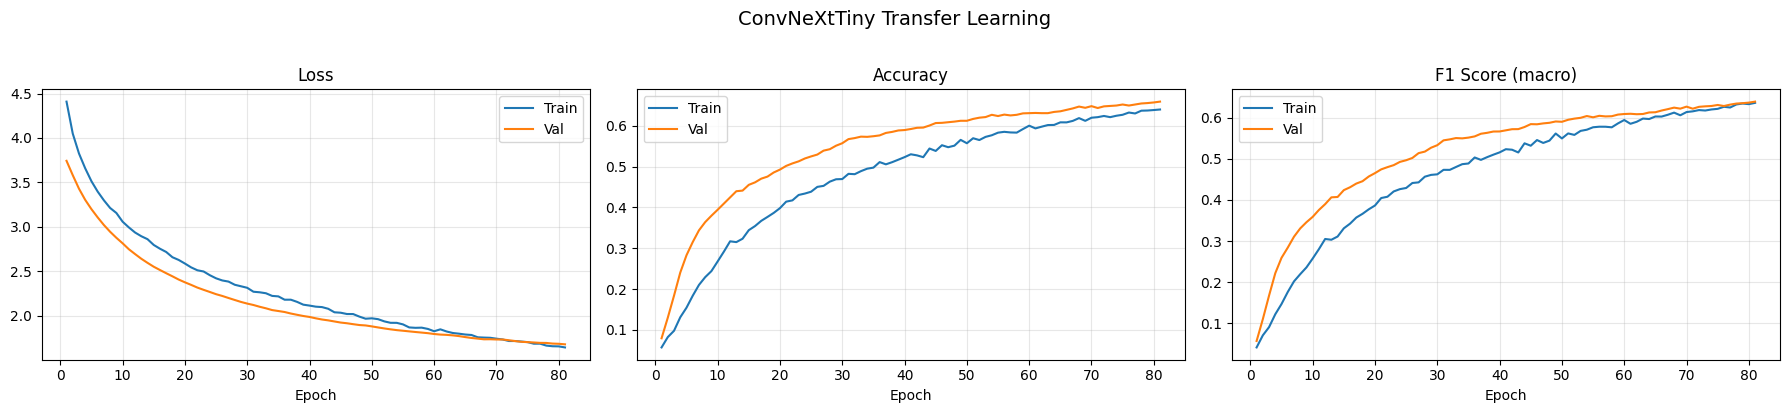

Best epoch (lowest val_loss): 81
  Val Loss: 1.6771
  Val Acc:  0.6596
  Val F1:   0.6390


In [9]:
plot_learning_curves([history_phase1, history_phase2], title="ConvNeXtTiny Transfer Learning")



  ConvNeXtTiny Transfer Learning - Test Evaluation
  Test Loss:     1.6390
  Test Accuracy: 0.6635
  Test F1 Macro: 0.6521

Classification Report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.82      0.64      0.72        87
      Boris_Kustodiev       0.47      0.33      0.39        67
     Camille_Pissarro       0.58      0.67      0.62        93
        Childe_Hassam       0.51      0.71      0.59        58
         Claude_Monet       0.77      0.56      0.65       141
          Edgar_Degas       0.57      0.69      0.62        65
        Eugene_Boudin       0.78      0.73      0.75        59
         Gustave_Dore       0.88      0.93      0.90        80
           Ilya_Repin       0.52      0.55      0.53        58
      Ivan_Aivazovsky       0.77      0.92      0.84        61
        Ivan_Shishkin       0.78      0.64      0.70        55
  John_Singer_Sargent       0.70      0.75      0.72        83
         Marc_Chagall       0.87

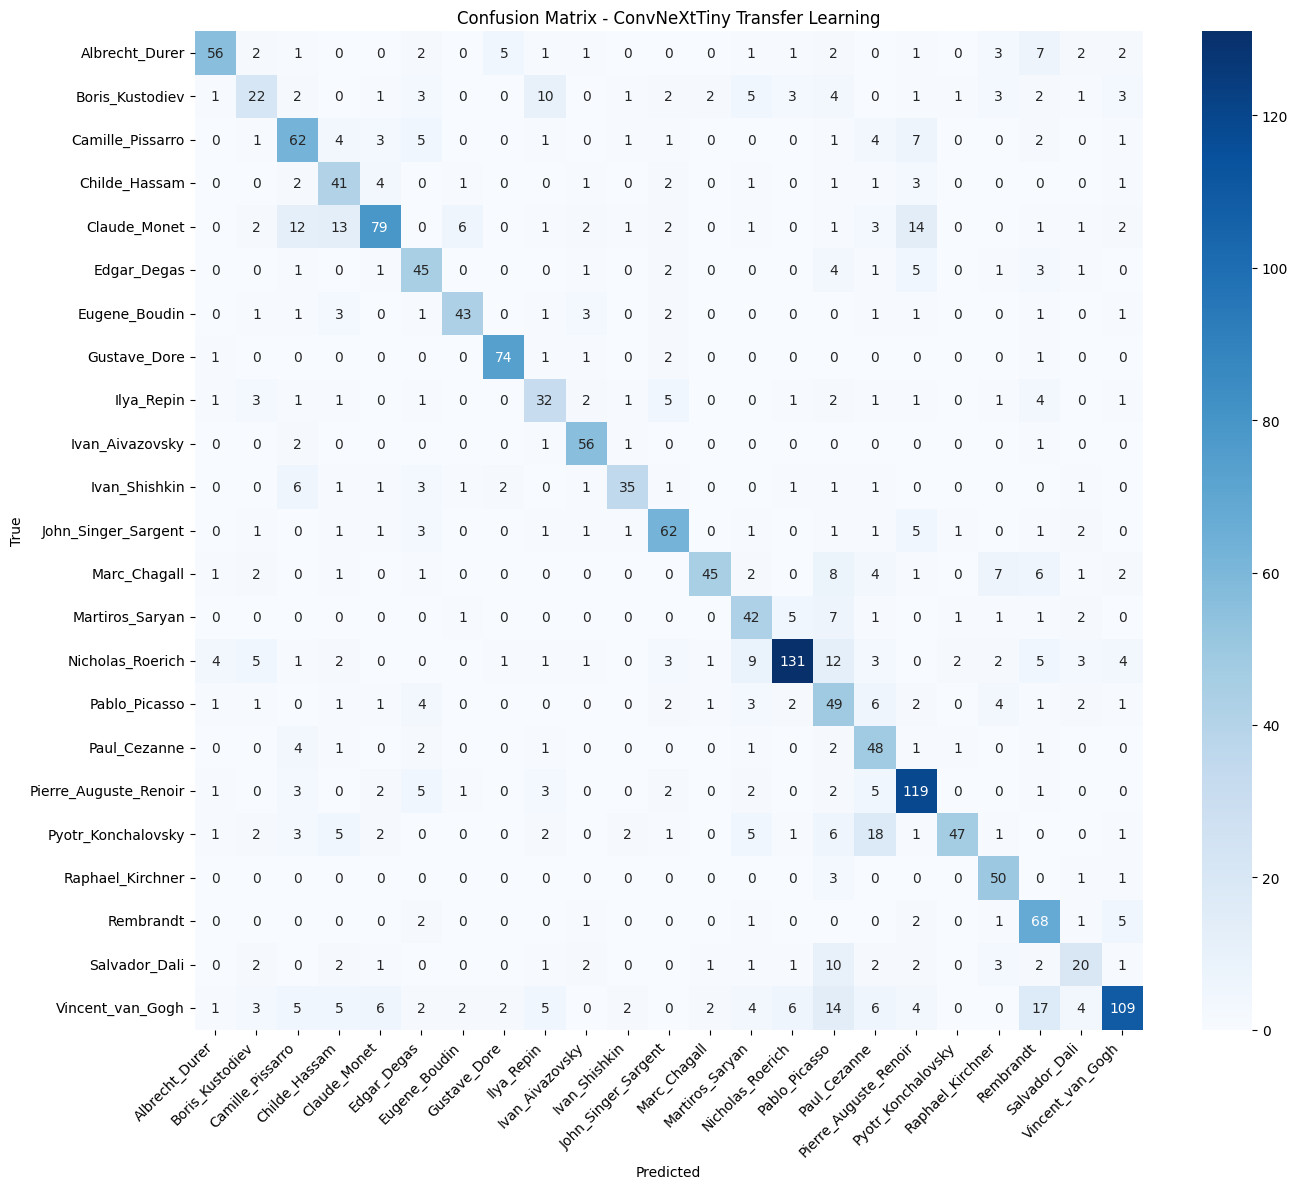

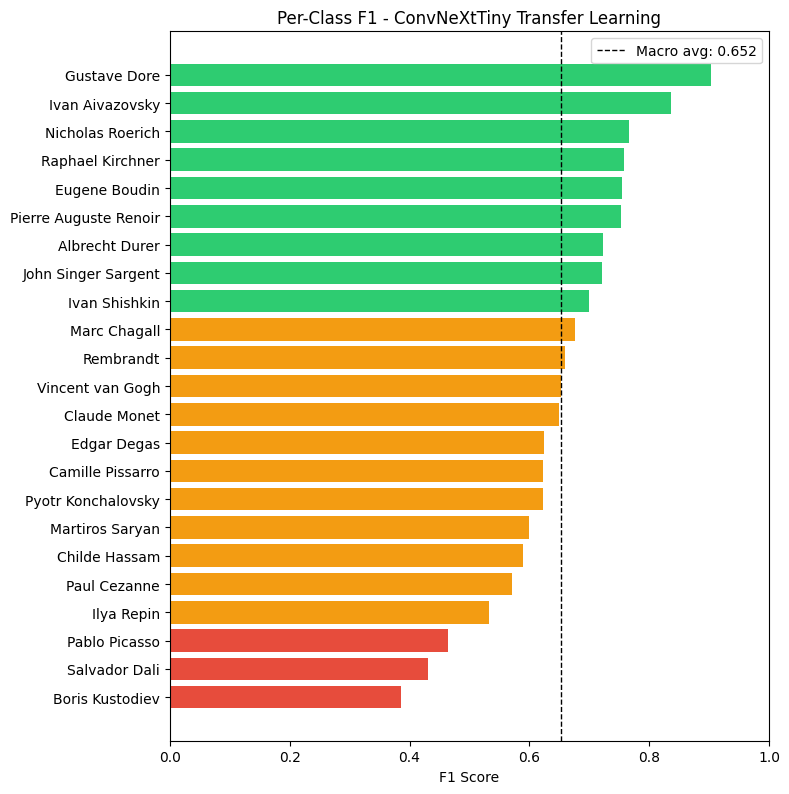

In [10]:
metrics_convnexttiny = evaluate_model(model, test_ds, class_names, "ConvNeXtTiny Transfer Learning")


In [11]:
save_history([history_phase1, history_phase2], config['models']['convnexttiny']['history'])


History saved to ../models/convnexttiny_history.json
